This is a Jupyter Notebook Script that will get data from pre-downloaded ISIMIP .nc files and find extract the locations where wind farms are currently located globally. For more information, reach out to Bryn Stecher (bs3157@barnard.edu)

In [1]:
%%time
import pandas as pd
import netCDF4 as nc
import dask.dataframe as dd 
import matplotlib as plt
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
import time
import hvplot as hv  
import hvplot.xarray  
import hvplot.xarray  # noqa


CPU times: total: 1.03 s
Wall time: 3.57 s


### Import Global Energy Model data, this contains all the locations of wind farms globally

Announced: Proposed projects that have been described in corporate or government plans or media releases but have not yet taken concrete steps such as applying for permits.

Pre-construction: Projects that are actively moving forward in seeking governmental approvals, land rights, or financing.

Construction: Site preparation and equipment installation are underway.

Operating: The project has been formally commissioned; commercial operation has begun.

In [281]:
gem_df = pd.read_excel('Global-Wind-Power-Tracker-May-2023.xlsx', sheet_name = 'Data')
gem_df['Points'] = gem_df['Latitude'].astype(str)+','+gem_df['Longitude'].astype(str)
gem = gem_df.loc[gem_df['Status'].isin(['operating', 'pre-construction', 'announced', 'construction'])]
gem.rename(columns = {'Latitude': 'lat', 'Longitude':'lon'}, inplace = True)
gem.lon = gem.lon.round(decimals=2) # this matches ISIMIP 
# only include sites that that have an installation type of ''offshore hard mount' 'offshore mount unknown'  'offshore floating'
gem = gem.loc[gem['Installation Type'].isin(['offshore hard mount', 'offshore mount unknown', 'offshore floating'])] # offshore
#gem = gem.loc[gem['Installation Type'].isin(['onshore'])] # onshore
#only keep United States
gem = gem.loc[gem['Country'].isin(['United States'])] # United States
gem.lat = gem.lat.round(decimals=2) # this matches ISIMIP 
gem.lon = gem.lon.round(decimals=2) # this matches ISIMIP 
gem.head()

C:\Users\bs3157\AppData\Local\Temp\ipykernel_15392\1612847212.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gem.rename(columns = {'Latitude': 'lat', 'Longitude':'lon'}, inplace = True)
C:\Users\bs3157\AppData\Local\Temp\ipykernel_15392\1612847212.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gem.lon = gem.lon.round(decimals=2) # this matches ISIMIP


,Date Last Researched,Country,Project Name,Phase Name,Project Name in Local Language / Script,Other Name(s),Capacity (MW),Installation Type,Status,Start year,...,"Major area (prefecture, district)",State/Province,Subregion,Region,GEM location ID,GEM phase ID,Other IDs (location),Other IDs (unit/phase),Wiki URL,Points
21562,2022-09-28,United States,Atlantic Shores Offshore Wind Project,1,NaN,NaN,1510.0,offshore hard mount,pre-construction,2027.0,...,NaN,New Jersey,Northern America,Americas,L907699,G910364,NaN,NaN,https://gem.wiki/Atlantic_Shores_Offshore_Wind...,"39.3171,-73.6179"
21589,2022-10-12,United States,Beacon wind farm,1,NaN,NaN,1230.0,offshore hard mount,pre-construction,2026.0,...,NaN,New York,Northern America,Americas,L907697,G910360,NaN,NaN,https://gem.wiki/Beacon_wind_farm,"41.0545,-70.45"
21590,2022-11-03,United States,Beacon wind farm,2,NaN,NaN,1170.0,offshore hard mount,announced,NaN,...,NaN,NaN,Northern America,Americas,L907697,G921341,NaN,NaN,https://gem.wiki/Beacon_wind_farm,"41.0545,-70.45"
21657,2021-11-04,United States,Block Island wind farm,1,NaN,NaN,30.0,offshore hard mount,operating,2016.0,...,NaN,Rhode Island,Northern America,Americas,L906543,G908832,EIA : 58035,NaN,https://gem.wiki/Block_Island_wind_farm,"41.1199,-71.5139"
21738,2022-09-30,United States,BW Ideol Floating Pilot wind farm,1,NaN,NaN,40.0,offshore floating,pre-construction,NaN,...,NaN,California,Northern America,Americas,L906607,G908909,NaN,NaN,https://gem.wiki/BW_Ideol_Floating_Pilot_wind_...,"34.7692,-120.904"


In [282]:
ds = xr.open_mfdataset('gfdl-esm4_r1i1p1f1_w5e5_ssp126_sfcwind_global_daily_2091_2100.nc', parallel=True) # INPUT .NC FILE  NAME HERE

In [283]:
ds

<xarray.Dataset>
Dimensions:  (lon: 720, lat: 360, time: 3652)
Coordinates:
  * lon      (lon) float64 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float64 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * time     (time) datetime64[ns] 2091-01-01 2091-01-02 ... 2100-12-31
Data variables:
    sfcwind  (time, lat, lon) float32 dask.array<chunksize=(3652, 360, 720), meta=np.ndarray>
Attributes:
    institution:  Potsdam Institute for Climate Impact Research (PIK)
    contact:      ISIMIP cross-sectoral science team <info@isimip.org> <https...
    references:   Lange (2019) <https://doi.org/10.5194/gmd-12-3055-2019> and...
    title:        ISIMIP3b bias-adjusted climate input data
    project:      Inter-Sectoral Impact Model Intercomparison Project phase 3...
    summary:      CMIP6 daily output data bias-adjusted and statistically dow...

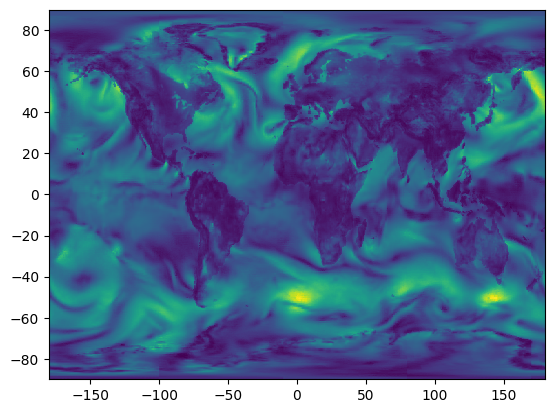

In [284]:
# plot the first timestep
lat = ds.sfcwind.lat.data  # numpy array
lon = ds.sfcwind.lon.data  # numpy array
sfcwind = ds.sfcwind.data  # numpy array
plt.figure()
plt.pcolormesh(lon, lat, sfcwind[0, :, :])

### Combine GEM and ISIMIP Data
#### We first need to convert GEM data from pandas to xarray dataset to properly merge the two together
#### ds = ISIMIP df = GEM

In [285]:
# Convert GEM data to xarray dataset
df = gem.to_xarray()

df = df.set_coords(("lat", "lon"))
df

<xarray.Dataset>
Dimensions:                                   (index: 39)
Coordinates:
  * index                                     (index) int64 21562 ... 23111
    lat                                       (index) float64 39.32 ... 33.82
    lon                                       (index) float64 -73.62 ... -78.36
Data variables: (12/28)
    Date Last Researched                      (index) object '2022-09-28' ......
    Country                                   (index) object 'United States' ...
    Project Name                              (index) object 'Atlantic Shores...
    Phase Name                                (index) object '1' '1' ... '1' '1'
    Project Name in Local Language / Script   (index) object nan nan ... nan nan
    Other Name(s)                             (index) object nan nan ... nan nan
    ...                                        ...
    GEM location ID                           (index) object 'L907699' ... 'L...
    GEM phase ID                              (index) object 'G910364' ... 'G...
    Other IDs (location)                      (index) object nan nan ... nan nan
    Other IDs (unit/phase)                    (index) object nan nan ... nan nan
    Wiki URL                                  (index) object 'https://gem.wik...
    Points                                    (index) object '39.3171,-73.617...

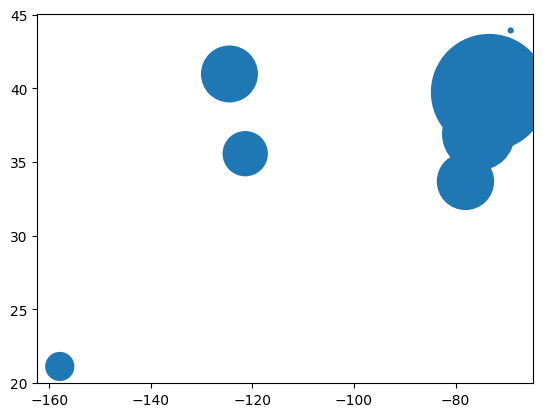

In [286]:
# plot the first timestep
lat = df['Capacity (MW)'].lat.data  # numpy array
lon = df['Capacity (MW)'].lon.data  # numpy array
cap = df['Capacity (MW)'].data  # numpy array
plt.figure()
plt.scatter(lon, lat, [cap]);

In [287]:
target_lon = df.lon
target_lat = df.lat 

da = ds.sel(lon=target_lon, lat=target_lat, method="nearest") # Finds on the ISIMIP data the closest coordinates to those on the wind farm database
da

<xarray.Dataset>
Dimensions:  (index: 39, time: 3652)
Coordinates:
    lon      (index) float64 -73.75 -70.25 -70.25 ... -70.75 -78.25 -78.25
    lat      (index) float64 39.25 41.25 41.25 41.25 ... 41.25 40.75 33.75 33.75
  * time     (time) datetime64[ns] 2091-01-01 2091-01-02 ... 2100-12-31
  * index    (index) int64 21562 21589 21590 21657 ... 23036 23037 23110 23111
Data variables:
    sfcwind  (time, index) float32 dask.array<chunksize=(3652, 39), meta=np.ndarray>
Attributes:
    institution:  Potsdam Institute for Climate Impact Research (PIK)
    contact:      ISIMIP cross-sectoral science team <info@isimip.org> <https...
    references:   Lange (2019) <https://doi.org/10.5194/gmd-12-3055-2019> and...
    title:        ISIMIP3b bias-adjusted climate input data
    project:      Inter-Sectoral Impact Model Intercomparison Project phase 3...
    summary:      CMIP6 daily output data bias-adjusted and statistically dow...

In [288]:
test123 = xr.combine_by_coords([ds, df]) # find overlap in coordinates
test123

<xarray.Dataset>
Dimensions:                                   (index: 39, lat: 360, lon: 720,
                                               time: 3652)
Coordinates:
  * index                                     (index) int64 21562 ... 23111
  * lat                                       (lat) float64 89.75 ... -89.75
  * lon                                       (lon) float64 -179.8 ... 179.8
  * time                                      (time) datetime64[ns] 2091-01-0...
Data variables: (12/29)
    Date Last Researched                      (index) object '2022-09-28' ......
    Country                                   (index) object 'United States' ...
    Project Name                              (index) object 'Atlantic Shores...
    Phase Name                                (index) object '1' '1' ... '1' '1'
    Project Name in Local Language / Script   (index) object nan nan ... nan nan
    Other Name(s)                             (index) object nan nan ... nan nan
    ...                                        ...
    GEM phase ID                              (index) object 'G910364' ... 'G...
    Other IDs (location)                      (index) object nan nan ... nan nan
    Other IDs (unit/phase)                    (index) object nan nan ... nan nan
    Wiki URL                                  (index) object 'https://gem.wik...
    Points                                    (index) object '39.3171,-73.617...
    sfcwind                                   (time, lat, lon) float32 dask.array<chunksize=(3652, 360, 720), meta=np.ndarray>
Attributes:
    institution:  Potsdam Institute for Climate Impact Research (PIK)
    contact:      ISIMIP cross-sectoral science team <info@isimip.org> <https...
    references:   Lange (2019) <https://doi.org/10.5194/gmd-12-3055-2019> and...
    title:        ISIMIP3b bias-adjusted climate input data
    project:      Inter-Sectoral Impact Model Intercomparison Project phase 3...
    summary:      CMIP6 daily output data bias-adjusted and statistically dow...

In [289]:
target_lon = df.lon
target_lat = df.lat 

lol = test123.sel(lon=target_lon, lat=target_lat, method="nearest") # find overlap in coordinates [nearest]
lol

<xarray.Dataset>
Dimensions:                                   (index: 39, time: 3652)
Coordinates:
  * index                                     (index) int64 21562 ... 23111
    lat                                       (index) float64 39.25 ... 33.75
    lon                                       (index) float64 -73.75 ... -78.25
  * time                                      (time) datetime64[ns] 2091-01-0...
Data variables: (12/29)
    Date Last Researched                      (index) object '2022-09-28' ......
    Country                                   (index) object 'United States' ...
    Project Name                              (index) object 'Atlantic Shores...
    Phase Name                                (index) object '1' '1' ... '1' '1'
    Project Name in Local Language / Script   (index) object nan nan ... nan nan
    Other Name(s)                             (index) object nan nan ... nan nan
    ...                                        ...
    GEM phase ID                              (index) object 'G910364' ... 'G...
    Other IDs (location)                      (index) object nan nan ... nan nan
    Other IDs (unit/phase)                    (index) object nan nan ... nan nan
    Wiki URL                                  (index) object 'https://gem.wik...
    Points                                    (index) object '39.3171,-73.617...
    sfcwind                                   (time, index) float32 dask.array<chunksize=(3652, 39), meta=np.ndarray>
Attributes:
    institution:  Potsdam Institute for Climate Impact Research (PIK)
    contact:      ISIMIP cross-sectoral science team <info@isimip.org> <https...
    references:   Lange (2019) <https://doi.org/10.5194/gmd-12-3055-2019> and...
    title:        ISIMIP3b bias-adjusted climate input data
    project:      Inter-Sectoral Impact Model Intercomparison Project phase 3...
    summary:      CMIP6 daily output data bias-adjusted and statistically dow...

In [290]:
lol

<xarray.Dataset>
Dimensions:                                   (index: 39, time: 3652)
Coordinates:
  * index                                     (index) int64 21562 ... 23111
    lat                                       (index) float64 39.25 ... 33.75
    lon                                       (index) float64 -73.75 ... -78.25
  * time                                      (time) datetime64[ns] 2091-01-0...
Data variables: (12/29)
    Date Last Researched                      (index) object '2022-09-28' ......
    Country                                   (index) object 'United States' ...
    Project Name                              (index) object 'Atlantic Shores...
    Phase Name                                (index) object '1' '1' ... '1' '1'
    Project Name in Local Language / Script   (index) object nan nan ... nan nan
    Other Name(s)                             (index) object nan nan ... nan nan
    ...                                        ...
    GEM phase ID                              (index) object 'G910364' ... 'G...
    Other IDs (location)                      (index) object nan nan ... nan nan
    Other IDs (unit/phase)                    (index) object nan nan ... nan nan
    Wiki URL                                  (index) object 'https://gem.wik...
    Points                                    (index) object '39.3171,-73.617...
    sfcwind                                   (time, index) float32 dask.array<chunksize=(3652, 39), meta=np.ndarray>
Attributes:
    institution:  Potsdam Institute for Climate Impact Research (PIK)
    contact:      ISIMIP cross-sectoral science team <info@isimip.org> <https...
    references:   Lange (2019) <https://doi.org/10.5194/gmd-12-3055-2019> and...
    title:        ISIMIP3b bias-adjusted climate input data
    project:      Inter-Sectoral Impact Model Intercomparison Project phase 3...
    summary:      CMIP6 daily output data bias-adjusted and statistically dow...

In [291]:
dask = lol[['lat', "lon", "sfcwind", 'Capacity (MW)', "City", 'Local area (taluk, county)', 'Major area (prefecture, district)', "State/Province","Region", 'Country']].to_dask_dataframe()

In [292]:
dask

,index,time,lat,lon,sfcwind,Capacity (MW),City,"Local area (taluk, county)","Major area (prefecture, district)",State/Province,Region,Country
npartitions=1,,,,,,,,,,,,
0,int64,datetime64[ns],float64,float64,float32,float64,object,object,object,object,object,object
142427,...,...,...,...,...,...,...,...,...,...,...,...


### Add Other Variables
These include capacity factors, wind speed at 80m, floor wind speed at 80m, and IEC Classification

In [293]:
# Adds the wind speeds for 80m 
dask['sfc_wind80m'] = dask['sfcwind']*((80/10)**0.143) 
# Adds the floor wind speeds for 80m 
dask['sfc_wind80m_floor'] = np.floor((dask['sfc_wind80m']) * 2) / 2
dask.sfc_wind80m = dask.sfc_wind80m.astype(float)
# merged_df.drop(['file', 'text', 'lat', 'lon'], axis=1, inplace=True) # Clean up data table

In [294]:
dask

,index,time,lat,lon,sfcwind,Capacity (MW),City,"Local area (taluk, county)","Major area (prefecture, district)",State/Province,Region,Country,sfc_wind80m,sfc_wind80m_floor
npartitions=1,,,,,,,,,,,,,,
0,int64,datetime64[ns],float64,float64,float32,float64,object,object,object,object,object,object,float64,float32
142427,...,...,...,...,...,...,...,...,...,...,...,...,...,...


In [295]:
dask.to_csv("ssp126_projectedstatus_usa_offshore_daily_2091_2100.csv", index=False, single_file=True)

['c:\\GitHub_Wind\\DATA_WIND_CF\\ssp126_projectedstatus_usa_offshore_daily_2091_2100.csv']